# Практика 7: Введение в графовые нейросети

Графовые нейросети (GNN) предназначены для работы с графовыми структурами. Устанавливаем `torch_geometric` (pip install torch_geometric). Загружаем датасет (`Cora`), где узлы — статьи, а рёбра — ссылки между ними. Используем `GCNConv` для построения графовой сверточной сети. Готовим данные: загружаем граф, переводим в тензоры, разбиваем на обучающую и тестовую выборки. Создаём нейросеть с `GCNConv`, добавляем активацию `ReLU`, реализуем механизм агрегации соседей (усреднение или сумма признаков). Обучаем модель, анализируем её точность, сравниваем с традиционными методами машинного обучения.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

torch.__version__

c:\Users\semen\works\NN2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.5.1+cu121'

In [2]:
SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [3]:
dataset = Planetoid(root="./data/Planetoid", name="Cora", transform=NormalizeFeatures())
data = dataset[0].to(device)

In [4]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)

        return x

In [5]:
model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=16,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

In [6]:
def train_step(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = (pred[mask] == data.y[mask]).sum().item()
    total = int(mask.sum())
    acc = correct / total

    return acc, pred, out

In [7]:
num_epochs = 200
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, num_epochs + 1):
    loss = train_step(model, data, optimizer, criterion)

    train_acc, _, _ = evaluate(model, data, data.train_mask)
    val_acc, _, _ = evaluate(model, data, data.val_mask)
    test_acc, _, _ = evaluate(model, data, data.test_mask)

    train_losses.append(loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

Epoch 001 | Loss: 1.9452 | Train Acc: 0.2357 | Val Acc: 0.1180 | Test Acc: 0.1400
Epoch 020 | Loss: 1.6947 | Train Acc: 0.8286 | Val Acc: 0.4940 | Test Acc: 0.5060
Epoch 040 | Loss: 1.3181 | Train Acc: 0.9714 | Val Acc: 0.7200 | Test Acc: 0.7320
Epoch 060 | Loss: 0.9081 | Train Acc: 0.9857 | Val Acc: 0.7580 | Test Acc: 0.7680
Epoch 080 | Loss: 0.6503 | Train Acc: 0.9929 | Val Acc: 0.7640 | Test Acc: 0.7850
Epoch 100 | Loss: 0.5140 | Train Acc: 0.9929 | Val Acc: 0.7780 | Test Acc: 0.8010
Epoch 120 | Loss: 0.4262 | Train Acc: 0.9929 | Val Acc: 0.7840 | Test Acc: 0.8110
Epoch 140 | Loss: 0.3711 | Train Acc: 0.9929 | Val Acc: 0.7720 | Test Acc: 0.8080
Epoch 160 | Loss: 0.3441 | Train Acc: 1.0000 | Val Acc: 0.7820 | Test Acc: 0.8080
Epoch 180 | Loss: 0.3205 | Train Acc: 1.0000 | Val Acc: 0.7760 | Test Acc: 0.8070
Epoch 200 | Loss: 0.3283 | Train Acc: 1.0000 | Val Acc: 0.7780 | Test Acc: 0.8060


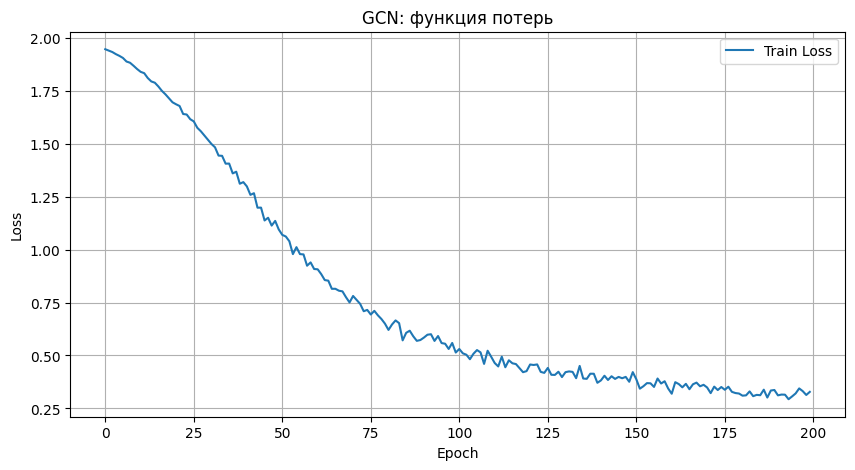

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN: функция потерь")
plt.grid(True)
plt.legend()
plt.show()

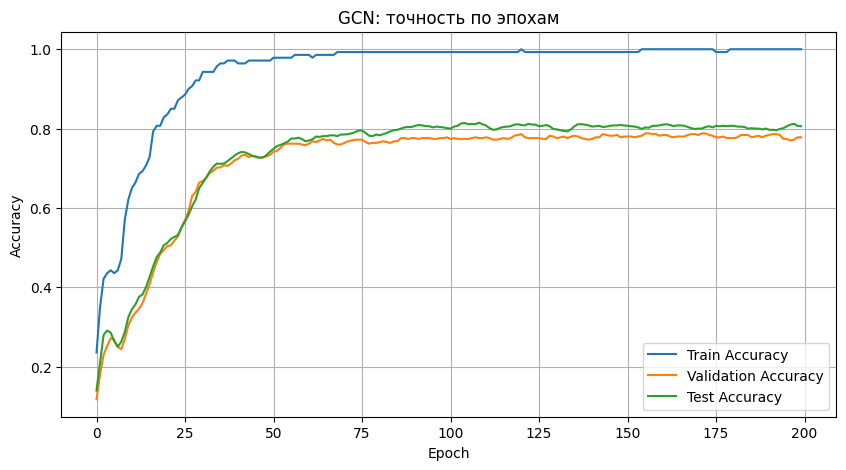

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN: точность по эпохам")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
y_true_test = data.y[data.test_mask].detach().cpu().numpy()
y_pred_test = pred[data.test_mask].detach().cpu().numpy()

print("Classification Report (GCN, test):")
print(classification_report(y_true_test, y_pred_test, digits=4))

Classification Report (GCN, test):
              precision    recall  f1-score   support

           0     0.6957    0.7385    0.7164       130
           1     0.7723    0.8571    0.8125        91
           2     0.8456    0.8750    0.8601       144
           3     0.9242    0.7649    0.8370       319
           4     0.7456    0.8456    0.7925       149
           5     0.8020    0.7864    0.7941       103
           6     0.6667    0.8125    0.7324        64

    accuracy                         0.8030      1000
   macro avg     0.7789    0.8114    0.7921      1000
weighted avg     0.8137    0.8030    0.8047      1000



In [15]:
X = data.x.detach().cpu().numpy()
y = data.y.detach().cpu().numpy()

train_mask = data.train_mask.detach().cpu().numpy()
test_mask = data.test_mask.detach().cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

clf = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

lr_test_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression test accuracy: {lr_test_acc:.4f}")
print(f"GCN test accuracy:                 {test_acc:.4f}")

Logistic Regression test accuracy: 0.5740
GCN test accuracy:                 0.8030


In [16]:
print("Classification Report (Logistic Regression, test):")
print(classification_report(y_test, y_pred_lr, digits=4))

Classification Report (Logistic Regression, test):
              precision    recall  f1-score   support

           0     0.5761    0.4077    0.4775       130
           1     0.4294    0.8022    0.5594        91
           2     0.5951    0.6736    0.6319       144
           3     0.7679    0.5392    0.6335       319
           4     0.6667    0.5503    0.6029       149
           5     0.5357    0.5825    0.5581       103
           6     0.3190    0.5781    0.4111        64

    accuracy                         0.5740      1000
   macro avg     0.5557    0.5905    0.5535      1000
weighted avg     0.6195    0.5740    0.5797      1000



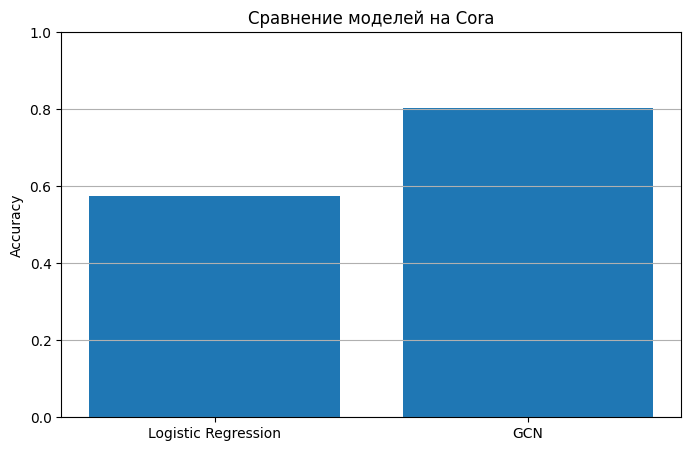

In [17]:
models = ["Logistic Regression", "GCN"]
scores = [lr_test_acc, test_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, scores)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Сравнение моделей на Cora")
plt.grid(axis="y")
plt.show()